# Week 3 - Day 3
Seaborn for Statistical Plots

# Objective
Analyze daily returns of 5 NIFTY stocks using Seaborn and visualize their relationships through correlation heatmaps and pairplots.

# Stocks Used
- Reliance
- TCS
- Infosys
- HDFC Bank
- ICICI Bank

In [48]:
import pandas as pd
import numpy as np
import yfinance as yf
import seaborn as sns
import matplotlib.pyplot as plt

## Download Historical Stock Data

Download 2 years of adjusted closing prices for 5 major Indian stocks using yfinance.

In [49]:
stocks = [
    "RELIANCE.NS",
    "TCS.NS",
    "INFY.NS",
    "HDFCBANK.NS",
    "ICICIBANK.NS"
]

data = yf.download(
    stocks,
    period="2y",
    auto_adjust=True
)

[*********************100%***********************]  5 of 5 completed


## Extract Closing Prices

We only need the Close prices for return calculations.

In [50]:
close_prices = data["Close"]

close_prices.head()

Ticker,HDFCBANK.NS,ICICIBANK.NS,INFY.NS,RELIANCE.NS,TCS.NS
Date,,,,,
2024-06-10,770.238708,1105.676514,1409.736938,1453.867432,3596.269531
2024-06-11,771.965393,1100.166870,1405.977051,1439.317871,3590.118896
2024-06-12,776.578003,1101.495117,1396.060181,1445.888672,3571.059326
2024-06-13,779.834045,1089.491699,1404.285034,1447.790771,3614.397217
2024-06-14,787.801270,1087.819214,1399.538208,1459.944092,3571.432129


## Compute Daily Returns

Daily Return = Percentage change from previous day's closing price.

In [51]:
returns = close_prices.pct_change().dropna()

returns.head()

Ticker,HDFCBANK.NS,ICICIBANK.NS,INFY.NS,RELIANCE.NS,TCS.NS
Date,,,,,
2024-06-11,0.002242,-0.004983,-0.002667,-0.010007,-0.001710
2024-06-12,0.005975,0.001207,-0.007053,0.004565,-0.005309
2024-06-13,0.004193,-0.010897,0.005891,0.001316,0.012136
2024-06-14,0.010217,-0.001535,-0.003380,0.008394,-0.011887
2024-06-18,0.006826,0.015556,0.006246,0.002352,-0.004423


## Correlation Matrix

Correlation helps identify how strongly stocks move together.

 +1 = Perfect positive relationship , 
 0 = No relationship , 
 -1 = Perfect negative relationship

In [52]:
corr_matrix = returns.corr()

corr_matrix

Ticker,HDFCBANK.NS,ICICIBANK.NS,INFY.NS,RELIANCE.NS,TCS.NS
Ticker,,,,,
HDFCBANK.NS,1.000000,0.539145,0.165882,0.341975,0.177851
ICICIBANK.NS,0.539145,1.000000,0.170154,0.260991,0.161897
INFY.NS,0.165882,0.170154,1.000000,0.219995,0.750307
RELIANCE.NS,0.341975,0.260991,0.219995,1.000000,0.286692
TCS.NS,0.177851,0.161897,0.750307,0.286692,1.000000


## Correlation Heatmap

Visual representation of correlations between stock returns.

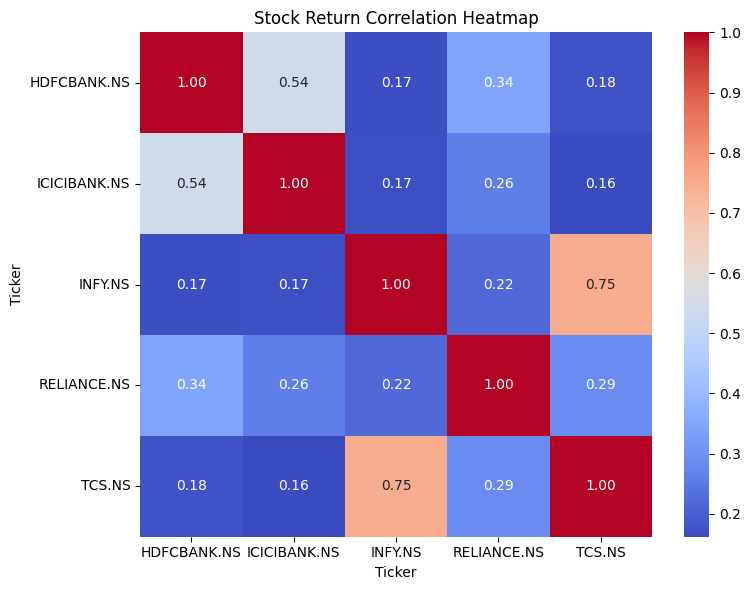

In [53]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Stock Return Correlation Heatmap")

plt.tight_layout()

plt.savefig(
    "../images/correlation_heatmap.png",
    dpi=150
)

plt.show()

## Pairplot of Daily Returns

Pairplot shows:

 Scatter plots between every pair of stocks ,   
 Distribution of each stock return on diagonal ,   
 Helps identify relationships and clusters

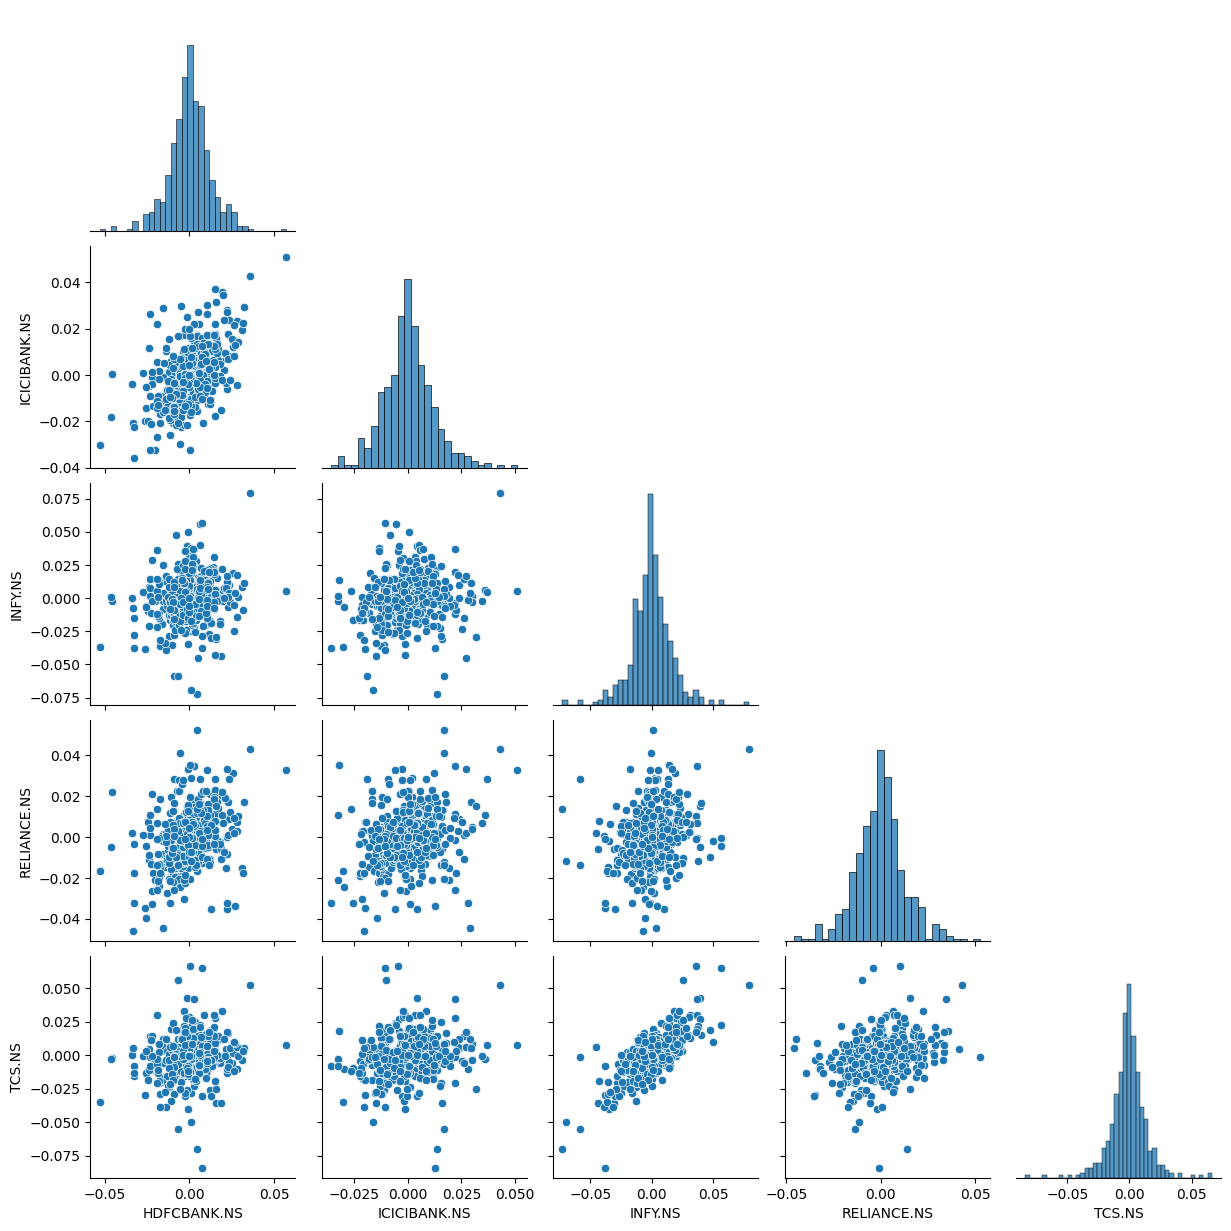

In [54]:
sns.pairplot(
    returns,
    corner=True
)

plt.show()

## Observations

1. Most NIFTY stocks show positive correlation.
2. Banking stocks tend to move together.
3. Pairplot helps visualize return distributions and relationships.
4. Heatmap makes correlation strength easy to identify.